In [1]:
import pandas as pd
df = pd.read_csv('/Users/aerilee/Documents/fraud-detection/data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.shape

(284807, 31)

In [3]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

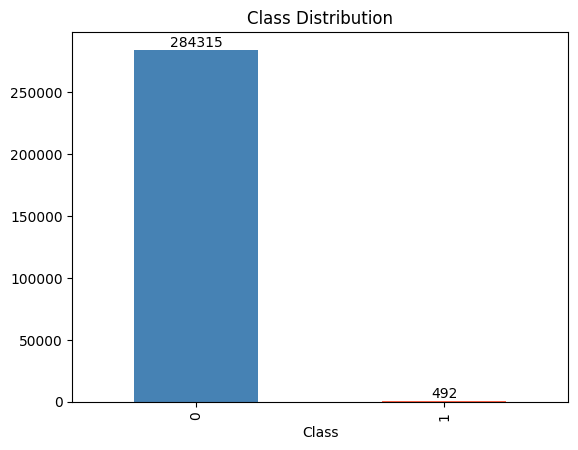

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = df['Class'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
ax.bar_label(ax.containers[0])

plt.title('Class Distribution')
plt.show()

#fraud vs normal transaction comparison

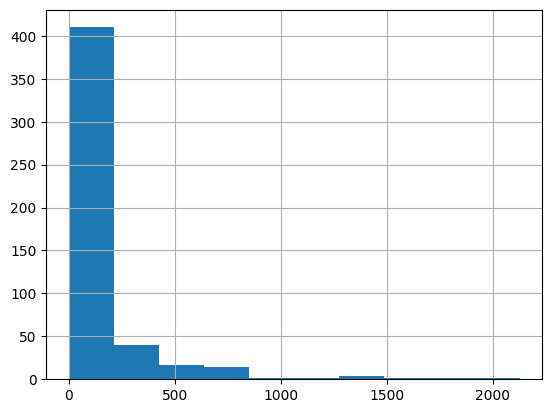

In [5]:

df[df['Class']==1]['Amount'].hist()
plt.show()

#Fraud-only amount distribution

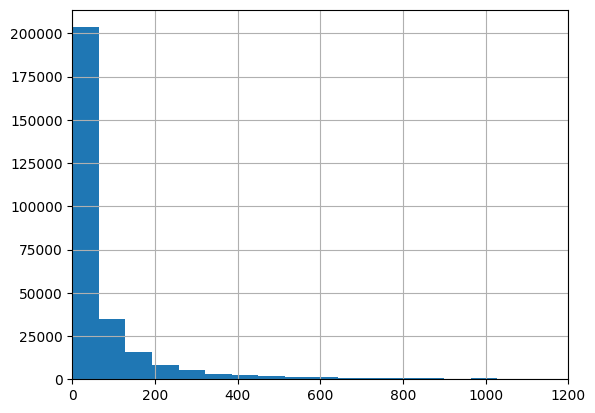

In [6]:
df[df['Class']==0]['Amount'].hist(bins=400)
plt.xlim(0, 1200)
plt.show()
#normal transaction distribution

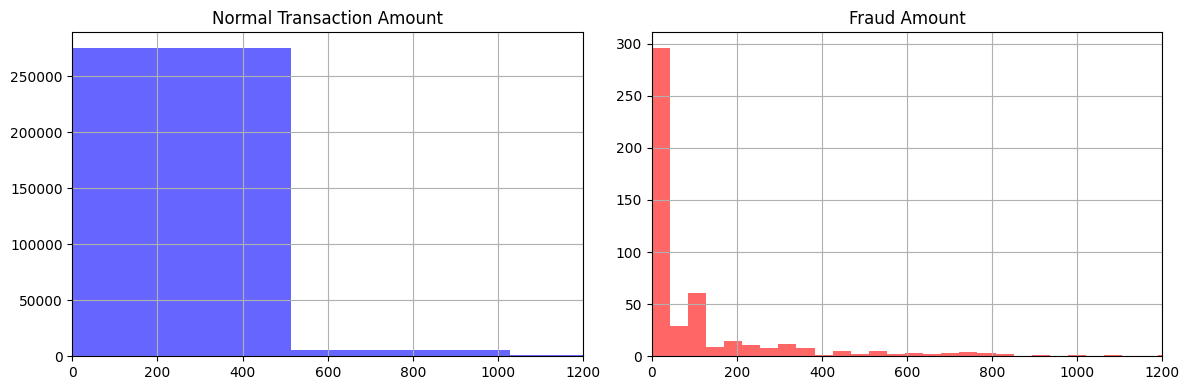

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


# Compare transaction amounts: normal vs fraud 
df[df['Class']==0]['Amount'].hist(bins=50, ax=ax1, color='blue', alpha=0.6)
ax1.set_title('Normal Transaction Amount')
ax1.set_xlim(0, 1200)

df[df['Class']==1]['Amount'].hist(bins=50, ax=ax2, color='red', alpha=0.6)
ax2.set_title('Fraud Amount')
ax2.set_xlim(0, 1200)

plt.tight_layout()
plt.show()




<Axes: >

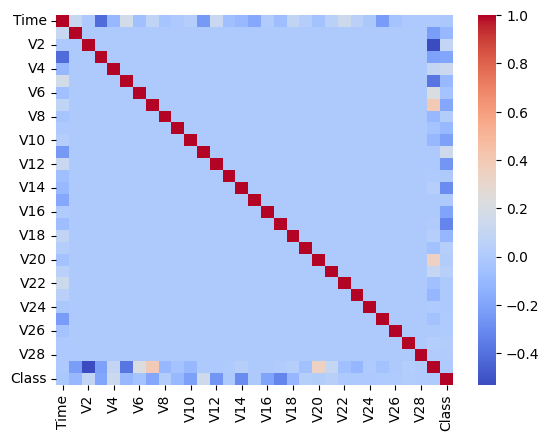

In [8]:
import seaborn as sns
sns.heatmap(df.corr(), cmap='coolwarm')

# Correlation heatmap across all features

In [9]:
# Sort features by correlation with Class
corr_with_class = df.corr()['Class'].sort_values()
print(corr_with_class)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# separating features from target (class)
X = df.drop('Class', axis=1)
y = df['Class']

# Train/test split (80/20), stratified to keep fraud ratio balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) #사기 케이스가 너무 적기 때문에 이걸 골고루 분포시키는게 stratify

# Scale features so Amount/Time don't dominate V1~V28
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) #새로 데이터에 평균/표준편차 구해서 스케일링하기 
X_test = scaler.transform(X_test) #위에서 한 값들도 스케일링

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

학습 데이터: (227845, 30)
테스트 데이터: (56962, 30)


In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Train baseline Logistic Regression (no class balancing yet)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
y_pred = model.predict(X_test)

# # Predict fraud labels (0/1) on test set

In [13]:
print(y_pred[:20])     # 앞에 20개만

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [14]:
print(f"사기로 예측한 것: {y_pred.sum()}개")
print(f"실제 사기: {y_test.sum()}개")

사기로 예측한 것: 75개
실제 사기: 98개


In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred)) #정답(y_test)랑 예측(y_pred)랑 얼마나 맞ㄷ았나 보여줘

# Compare predictions vs truth

# precision: of predicted frauds, how many were real?
# recall:    of real frauds, how many did we catch?
# f1:        harmonic mean of precision and recall
# support:   actual count of each class in y_test

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [16]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56851    13]
 [   36    62]]


In [17]:
model2 = LogisticRegression(max_iter=1000, class_weight='balanced') # 사기인데 놓친 경우의 벌점을 높이기
model2.fit(X_train, y_train) #다시 이 트레인 값들로 트레이닝 시킴 
y_pred2 = model2.predict(X_test)

print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

[[55478  1386]
 [    8    90]]


In [18]:
proba = model.predict_proba(X_test)[:, 1]  # 사기 확률만
y_pred_custom = (proba >= 0.5).astype(int)  # 0.5 이상만 사기

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[56851    13]
 [   36    62]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
proba2 = model2.predict_proba(X_test)[:, 1]  # 사기 확률만
y_pred_custom = (proba2 >= 0.20).astype(int)  # 0.2 이상만 사기

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[51349  5515]
 [    6    92]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     56864
           1       0.02      0.94      0.03        98

    accuracy                           0.90     56962
   macro avg       0.51      0.92      0.49     56962
weighted avg       1.00      0.90      0.95     56962



In [23]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model3.fit(X_train, y_train)
proba3 = model3.predict_proba(X_test)[:, 1]
y_pred3 = (proba3 >= 0.5).astype(int)
print(classification_report(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56861     3]
 [   25    73]]


In [21]:
y_pred3_low = (proba3 >= 0.3).astype(int)
print(classification_report(y_test, y_pred3_low))
print(confusion_matrix(y_test, y_pred3_low))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.85      0.88        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56857     7]
 [   15    83]]
